In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from ROHSApy import ROHSA

fitsname = "./baseline/CRAFTS_-4.7_-350_-150_baseline.fits"
hdu = fits.open(fitsname)
hdr = hdu[0].header
cube = hdu[0].data

In [2]:
print(hdu[0].data.shape)

(994, 89, 153)


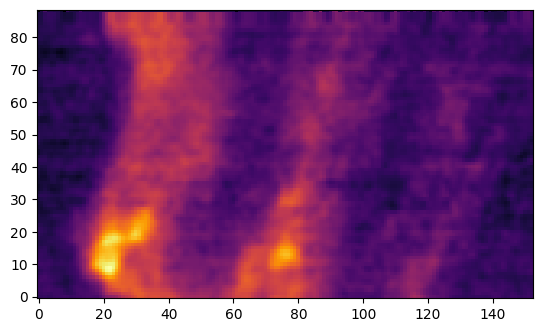

In [3]:
plt.figure()
plt.imshow(np.sum(cube,0), origin="lower", cmap="inferno")

In [ ]:
filename = "GHIGLS_DFN_Tb_3D.dat" #@param
fileout = "./baseline/ROHSA_3ngauss_3D_1.1.1.0_retest.dat" #@param
filename_noise = ''
n_gauss = 3    #@param {type:"slider", min:1, max:12, step:1}                                                                                                                                                                                                                             
lambda_amp = 1     #@param {type:"slider", min:0, max:1000, step:1}
lambda_mu = 1   #@param {type:"slider", min:0, max:1000, step:1}
lambda_sig = 1   #@param {type:"slider", min:0, max:1000, step:1}
lambda_var_sig = 0.   #@param {type:"slider", min:0, max:10000, step:1}                                                                                                                                                                                                                                                            
amp_fact_init = 0.66  # times max amplitude of Gaussians for the fit of the mean spectrum                                                                                                                                                                                                                                                       
sig_init = 4.         # dispersion of Gaussians for the fit of the mean spectrum
lb_sig_init = 1.      # lower limit on sigma for the fit of the mean spectrum
ub_sig_init = 12.     # upper limit on sigma for the fit of the mean spectrum
lb_sig = 1.
ub_sig = 100.                                                                                                                                                                                                                                                                
maxiter_init = 15000  # max iteration for L-BFGS-B alogorithm init mean                                                                                                                                                                                                                                        
maxiter = 800         #@param {type:"slider", min:1, max:800, step:1}                                                                                                                                                                                                                                                         
noise = ".false."     # if false - STD map computed by ROHSA between lstd and ustd                                                                                                                                                                                                           
lstd = 1              #@param {type:"slider", min:1, max:400, step:1}                                                                                                                                                                                                                
ustd = 20             #@param {type:"slider", min:1, max:400, step:1}                                                                                                                                                                                                                 
iprint = -1           #@param ["-1", "0", "1"]                                                                                                                                                                                                                                                                                      
iprint_init = -1      # print option init                                              
save_grid = ".false." #@param [".true.", ".false."] 
init_spec =".true."
filename_init_spec = "ngauss_3.txt"


core = ROHSA(cube)            
core.cube2dat(filename=filename)
core.gen_parameters_3D(filename=filename, 
                    fileout=fileout,  
                    n_gauss=n_gauss,
                    lambda_amp=lambda_amp,
                    lambda_mu=lambda_mu,
                    lambda_sig=lambda_sig,
                    lambda_var_sig=lambda_var_sig,
                    amp_fact_init=amp_fact_init,
                    sig_init=sig_init,
                    lb_sig_init=lb_sig_init,
                    ub_sig_init=ub_sig_init,
                    lb_sig=lb_sig,
                    ub_sig=ub_sig,
                    noise=noise,
                    maxiter=maxiter,
                    lstd=lstd,
                    ustd=ustd,
                    iprint_init=iprint_init,
                    iprint=iprint,
                    save_grid=save_grid,
                      init_spec = init_spec,
                   filename_init_spec=filename_init_spec)

In [ ]:
!./ROHSA/src/ROHSA parameters.txt

In [7]:
core = ROHSA(cube)    

In [8]:
gaussian = core.read_gaussian("./baseline/ROHSA_3ngauss_3D_1.1.1.0_retest.dat")
print("dim cube = " + str(gaussian.shape))

model = core.return_result_cube(gaussian=gaussian) #可以改变从而绘制真正的速度
# gaussian_phys = core.physical_gaussian(gaussian)
amplitude = gaussian[0::3]
position = gaussian[1::3]
dispersion = gaussian[2::3]

integral = amplitude * dispersion

Opening data file
dim cube = (9, 89, 153)


In [9]:
# 假设您有FITS文件
from astropy.io import fits

core.hdr = hdr

gaussian_phys = core.physical_gaussian(gaussian)

if isinstance(gaussian_phys, np.ndarray):
    print("转换成功！")
    print("物理参数形状:", gaussian_phys.shape)
    
    # 提取物理单位的高斯参数
    amplitude_phys = gaussian_phys[0::3]      # 振幅（不变）
    velocity_phys = gaussian_phys[1::3]       # 中心速度 (km/s)
    dispersion_phys = gaussian_phys[2::3]     # 速度宽度 (km/s)
    
    print(f"速度范围: {velocity_phys.min():.2f} 到 {velocity_phys.max():.2f} km/s")
    print(f"宽度范围: {dispersion_phys.min():.2f} 到 {dispersion_phys.max():.2f} km/s")

转换成功！
物理参数形状: (9, 89, 153)
速度范围: -0.30 到 -0.22 km/s
宽度范围: 0.00 到 0.02 km/s


In [10]:
amplitude = gaussian_phys[0::3]
position = gaussian_phys[1::3]
dispersion = gaussian_phys[2::3]

integral = amplitude * dispersion

/tmp/ipykernel_1830/4291648137.py:7: RuntimeWarning: divide by zero encountered in divide
  plt.imshow((np.sum(gaussian_phys,0)-np.sum(cube,0))/np.sum(model,0), origin="lower", cmap="inferno")


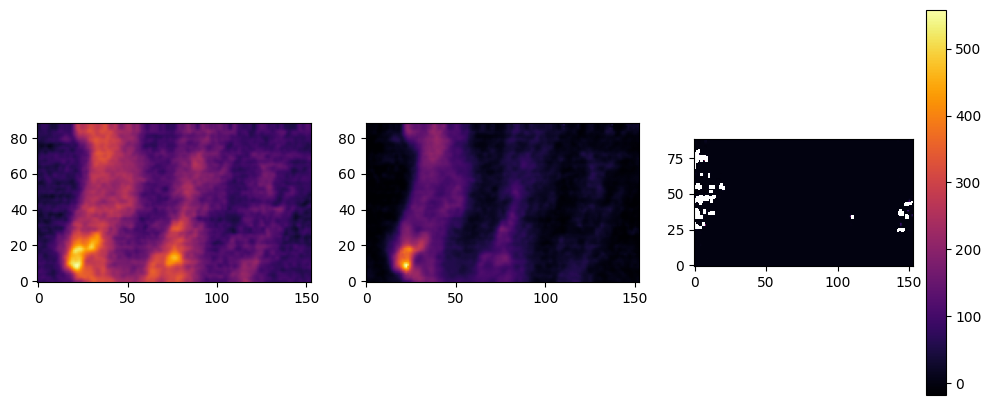

In [11]:
plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
plt.imshow(np.sum(cube,0), origin="lower", cmap="inferno")
plt.subplot(1,3,2)
plt.imshow(np.sum(gaussian_phys,0), origin="lower", cmap="inferno")
plt.subplot(1,3,3)
plt.imshow((np.sum(gaussian_phys,0)-np.sum(cube,0))/np.sum(model,0), origin="lower", cmap="inferno")
plt.colorbar()

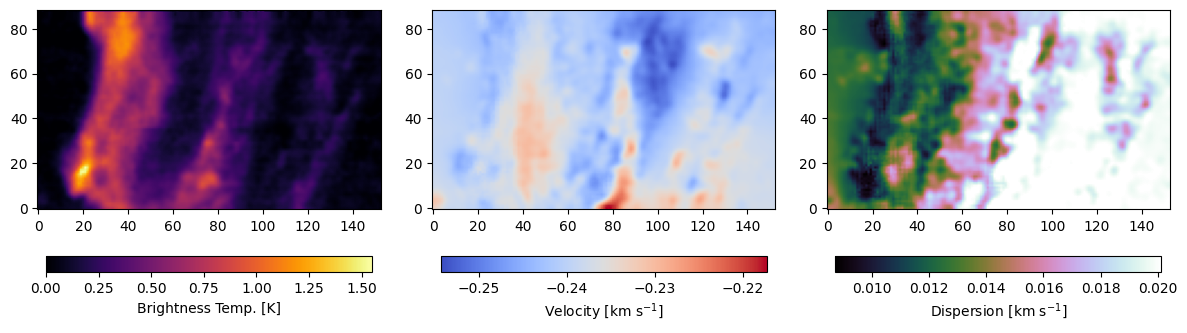

In [12]:
i = 0

plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
im1 = plt.imshow(amplitude[i], origin="lower", cmap="inferno")
cbar1 = plt.colorbar(im1, shrink=0.95, pad=0.1, location = 'bottom')  # 添加colorbar在下方
cbar1.set_label('Brightness Temp. [K]')

plt.subplot(1,3,2)
im2 = plt.imshow(position[i], origin="lower", cmap="coolwarm" )
cbar2 = plt.colorbar(im2, shrink=0.95, pad=0.1, location = 'bottom')  # 添加colorbar在下方
cbar2.set_label('Velocity [km s$^{-1}$]')

plt.subplot(1,3,3)
im3 = plt.imshow(dispersion[i], origin="lower", cmap="cubehelix")
cbar3 = plt.colorbar(im3, shrink=0.95, pad=0.1, location = 'bottom')  # 添加colorbar在下方
cbar3.set_label('Dispersion [km s$^{-1}$]')

plt.tight_layout()  # 自动调整布局，避免重叠
plt.show()

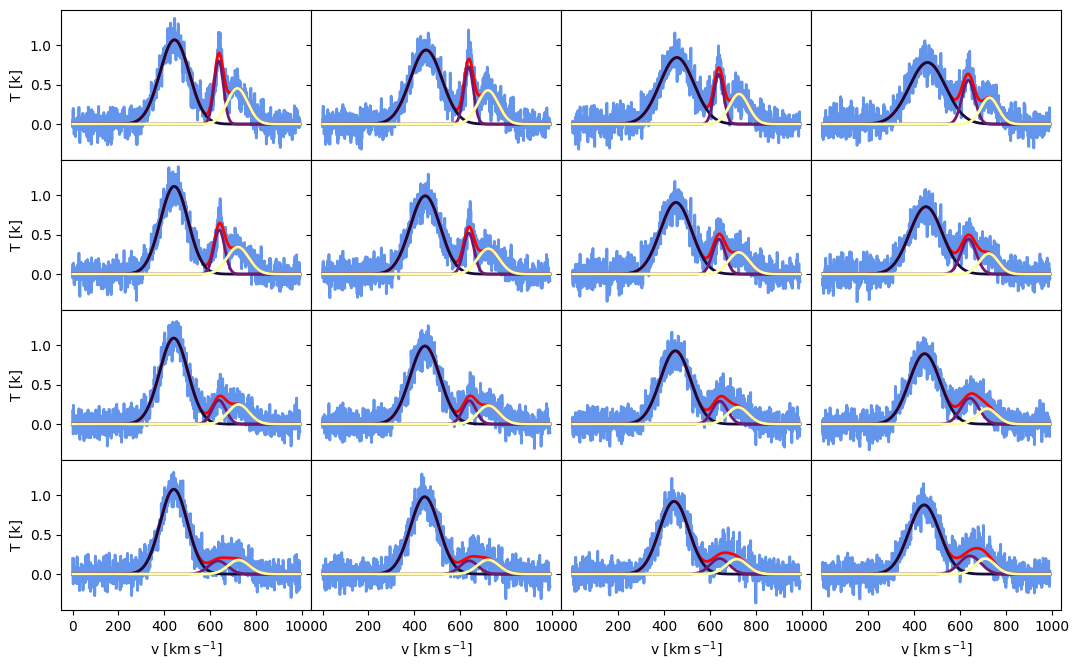

In [14]:
#Plot mosaic spectra                                                                                                                                                                 
pvalues = np.logspace(-1, 0, len(integral))
pmin = pvalues[0]
pmax = pvalues[-1]

def norm(pval):
    return (pval - pmin) / float(pmax - pmin)

ny = 4; nx = 4
# center_y = int(cube.shape[2]/6); center_x = int(cube.shape[1]/6)
# center_y = 20; center_x = 77
center_y = 18; center_x = 24
# center_y = 80; center_x = 230
x = np.arange(cube.shape[0])
cb = "magenta"
cw = "crimson"
fig, axs = plt.subplots(4, 4, sharex=True, sharey=True, figsize=(10.,6.))
fig.subplots_adjust(hspace=0, wspace=0, left=0, right=1, top=1, bottom=0)
for i in np.arange(ny):
    for j in np.arange(nx):
        axs[i][j].step(x, cube[:,center_y+i,center_x+j], color='cornflowerblue', linewidth=2.)
        axs[i][j].plot(x, model[:,center_y+i,center_x+j], linestyle="-", linewidth=2., color="r")
        for k in range(len(integral)):
            axs[i][j].plot(x, core.gauss(x, gaussian[0::3][k][center_y+i,center_x+j],
                                            gaussian[1::3][k][center_y+i,center_x+j], 
                                            gaussian[2::3][k][center_y+i,center_x+j]),
                           linewidth=2., color=plt.cm.inferno(pvalues[k]))
        if j == 0: axs[i][j].set_ylabel(r'T [k]')
        axs[i][j].set_xlabel(r'v [km s$^{-1}$]')
# plt.savefig("plot/" + 'mosaic_spectra_all.png', format='png', bbox_inches='tight', pad_inches=0.02)

In [15]:
core.hdr = hdr

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from scipy import ndimage
from mpl_toolkits.axes_grid1 import make_axes_locatable
import os
import warnings
warnings.filterwarnings('ignore')



# ==================== 1. 读取ROHSA结果（同时保留像素单位和物理单位） ====================
def read_rohsa_results(gaussian_file):
    """
    读取ROHSA的输出结果(.dat格式)
    返回像素单位和物理单位的结果
    """
    print("\n" + "="*60)
    print("READING ROHSA RESULTS")
    print("="*60)
    
    # 使用core模块读取像素单位的gaussian
    print("Reading Gaussian parameters (pixel units)...")
    gaussian_pixel = core.read_gaussian(gaussian_file)
    
    print(f"Gaussian pixel array shape: {gaussian_pixel.shape}")
    print(f"Data type: {gaussian_pixel.dtype}")
    model = core.return_result_cube(gaussian=gaussian_pixel)
    
    # 转换为物理单位
    print("Converting to physical units...")
    gaussian_physical = core.physical_gaussian(gaussian_pixel)
    
    # 解析维度: (n_parameters * n_components, n_y, n_x)
    n_params_times_comp, n_y, n_x = gaussian_pixel.shape
    n_components = n_params_times_comp // 3
    
    print(f"Spatial dimensions: {n_x} × {n_y}")
    print(f"Number of Gaussian components: {n_components}")
    
    # 提取像素单位的参数
    amplitude_pixel = gaussian_pixel[0::3].transpose(2, 1, 0)  # [n_x, n_y, n_comp]
    position_pixel = gaussian_pixel[1::3].transpose(2, 1, 0)   # [n_x, n_y, n_comp]
    dispersion_pixel = gaussian_pixel[2::3].transpose(2, 1, 0) # [n_x, n_y, n_comp]
    
    # 提取物理单位的参数
    amplitude_phys = gaussian_physical[0::3].transpose(2, 1, 0)  # [n_x, n_y, n_comp]
    position_phys = gaussian_physical[1::3].transpose(2, 1, 0)   # [n_x, n_y, n_comp]
    dispersion_phys = gaussian_physical[2::3].transpose(2, 1, 0) # [n_x, n_y, n_comp]
    
    # 清理无效值
    amplitude_pixel = np.nan_to_num(amplitude_pixel)
    position_pixel = np.nan_to_num(position_pixel)
    dispersion_pixel = np.nan_to_num(np.abs(dispersion_pixel))
    
    amplitude_phys = np.nan_to_num(amplitude_phys)
    position_phys = np.nan_to_num(position_phys)
    dispersion_phys = np.nan_to_num(np.abs(dispersion_phys))
    
    print(f"\nPixel units statistics:")
    for comp in range(n_components):
        amp_comp = amplitude_pixel[:, :, comp]
        amp_nonzero = amp_comp[amp_comp > 0]
        if len(amp_nonzero) > 0:
            print(f"  Component {comp+1} amplitude (pixel): range [{np.min(amp_nonzero):.4f}, {np.max(amp_comp):.4f}]")
    
    print(f"\nPhysical units statistics:")
    for comp in range(n_components):
        amp_comp = amplitude_phys[:, :, comp]
        amp_nonzero = amp_comp[amp_comp > 0]
        if len(amp_nonzero) > 0:
            print(f"  Component {comp+1} amplitude (K): range [{np.min(amp_nonzero):.4f}, {np.max(amp_comp):.4f}]")
    
    return {
        'pixel': {
            'amplitude': amplitude_pixel,
            'position': position_pixel,
            'dispersion': dispersion_pixel,
        },
        'physical': {
            'amplitude': amplitude_phys,
            'position': position_phys,
            'dispersion': dispersion_phys,
        },
        'n_components': n_components,
        'shape': (n_x, n_y),
        'original_pixel': gaussian_pixel,
        'original_physical': gaussian_physical
    }

# ==================== 2. 读取原始FITS数据 ====================
def read_original_fits(fits_file):
    """读取原始FITS文件"""
    print("\n" + "="*60)
    print("READING ORIGINAL FITS")
    print("="*60)
    
    try:
        hdu = fits.open(fits_file)[0]
        cube = hdu.data
        header = hdu.header
        
        print(f"Original cube shape: {cube.shape}")
        print(f"Data range: [{np.min(cube):.4f}, {np.max(cube):.4f}]")
        
        # 获取速度信息（如果有）
        if 'CRVAL3' in header and 'CDELT3' in header and 'NAXIS3' in header:
            v0 = header['CRVAL3']
            dv = header['CDELT3']
            n_channels = header['NAXIS3']
            velocities = v0 + np.arange(n_channels) * dv
            print(f"Velocity range: [{velocities[0]:.2f}, {velocities[-1]:.2f}] km/s")
        else:
            velocities = None
            print("No velocity information in header")
        
        return cube, header, velocities
        
    except Exception as e:
        print(f"Error reading FITS file: {e}")
        return None, None, None

# ==================== 3. 从数据计算每个像素的噪声 ====================
def calculate_per_pixel_noise(original_cube, output_dir, noise_channels=None, velocities=None):
    """
    从数据立方体中计算每个像素的噪声
    """
    print("\n" + "="*60)
    print("CALCULATING PER-PIXEL NOISE FROM DATA")
    print("="*60)
    
    if original_cube is None:
        print("No original cube data available")
        return None, None
    
    n_channels, n_y, n_x = original_cube.shape
    
    if noise_channels is None:
        # 自动选择：前10%和后10%的通道作为噪声
        n_noise = max(10, int(n_channels * 0.1))
        noise_channels_indices = [0, n_noise, n_channels - n_noise, n_channels]
        print(f"Auto-selected noise channels: indices {noise_channels_indices}")
    else:
        noise_channels_indices = noise_channels
        print(f"Using specified noise channels: {noise_channels_indices}")
    
    # 提取噪声通道的数据
    start1, end1, start2, end2 = noise_channels_indices
    noise_data1 = original_cube[start1:end1, :, :]
    noise_data2 = original_cube[start2:end2, :, :]
    noise_data = np.concatenate([noise_data1, noise_data2], axis=0)
    
    print(f"Using {len(noise_data)} channels for noise calculation")
    
    # 计算每个像素的RMS
    noise_rms_map = np.std(noise_data, axis=0)  # [n_y, n_x]
    global_noise_rms = np.mean(noise_rms_map)
    
    print(f"\nPer-pixel noise statistics (K):")
    print(f"  Global mean RMS: {global_noise_rms:.4f}")
    print(f"  RMS range: [{np.min(noise_rms_map):.4f}, {np.max(noise_rms_map):.4f}]")
    print(f"  RMS median: {np.median(noise_rms_map):.4f}")
    
    # 显示噪声分布的直方图
    plt.figure(figsize=(10, 6))
    plt.hist(noise_rms_map.flatten(), bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    plt.axvline(global_noise_rms, color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {global_noise_rms:.4f} K')
    plt.axvline(np.median(noise_rms_map), color='green', linestyle='--', linewidth=2,
                label=f'Median: {np.median(noise_rms_map):.4f} K')
    plt.xlabel('Noise RMS [K]', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Distribution of Per-Pixel Noise RMS', fontsize=14)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    # 保存直方图
    hist_file = os.path.join(output_dir, 'noise_distribution.png')
    plt.savefig(hist_file, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Noise distribution histogram saved to: {hist_file}")
    
    return noise_rms_map, global_noise_rms

# ==================== 4. 对每个成分单独进行振幅筛选 ====================
def filter_each_component_with_per_pixel_noise(rohsa_results, noise_rms_map, snr_threshold=2.0):
    """
    对每个高斯成分单独进行振幅筛选
    amplitude < snr_threshold * noise_at_this_pixel 的像素设为0
    
    注意：筛选基于物理单位的振幅，但返回的mask应用于像素单位的数据
    """
    print("\n" + "="*60)
    print("FILTERING EACH COMPONENT WITH PER-PIXEL NOISE")
    print("="*60)
    print(f"SNR threshold: {snr_threshold}σ")
    
    if noise_rms_map is None:
        print("No noise map available, skipping filtering")
        return rohsa_results, None, None
    
    # 使用物理单位的振幅进行SNR计算
    amplitude_phys = rohsa_results['physical']['amplitude'].copy()  # [n_x, n_y, n_comp] 单位: K
    n_components = rohsa_results['n_components']
    n_x, n_y, _ = amplitude_phys.shape
    
    # 扩展噪声图以匹配振幅的维度
    noise_expanded = noise_rms_map.T[:, :, np.newaxis]  # [n_x, n_y, 1]
    
    # 计算每个像素、每个分量的SNR
    with np.errstate(divide='ignore', invalid='ignore'):
        snr_maps = amplitude_phys / (noise_expanded + 1e-10)
        snr_maps = np.nan_to_num(snr_maps)
    
    print(f"\nSNR statistics before filtering:")
    for comp in range(n_components):
        comp_snr = snr_maps[:, :, comp]
        valid_snr = comp_snr[amplitude_phys[:, :, comp] > 0]
        if len(valid_snr) > 0:
            print(f"  Component {comp+1}: SNR range [{np.min(valid_snr):.2f}, {np.max(valid_snr):.2f}], "
                  f"mean {np.mean(valid_snr):.2f}")
    
    # 生成每个成分的mask（基于物理单位的SNR）
    masks = snr_maps >= snr_threshold  # [n_x, n_y, n_comp]
    
    print(f"\nPer component statistics after filtering:")
    for comp in range(n_components):
        orig_pixels = np.sum(amplitude_phys[:, :, comp] > 0)
        keep_pixels = np.sum(masks[:, :, comp])
        
        if orig_pixels > 0:
            retention = 100 * keep_pixels / orig_pixels
        else:
            retention = 0
            
        percent_total = 100 * keep_pixels / (n_x * n_y)
        print(f"  Component {comp+1}:")
        print(f"    Original non-zero: {orig_pixels}")
        print(f"    Kept: {keep_pixels} ({percent_total:.2f}% of total, {retention:.2f}% of original)")
        
        # 计算保留像素的最小SNR
        kept_snr = snr_maps[:, :, comp][masks[:, :, comp]]
        if len(kept_snr) > 0:
            print(f"    Kept SNR range: [{np.min(kept_snr):.2f}, {np.max(kept_snr):.2f}]")
    
    # 创建筛选后的结果（包含像素单位和物理单位）
    filtered_results = {
        'pixel': {
            'amplitude': rohsa_results['pixel']['amplitude'].copy(),
            'position': rohsa_results['pixel']['position'].copy(),
            'dispersion': rohsa_results['pixel']['dispersion'].copy(),
        },
        'physical': {
            'amplitude': rohsa_results['physical']['amplitude'].copy(),
            'position': rohsa_results['physical']['position'].copy(),
            'dispersion': rohsa_results['physical']['dispersion'].copy(),
        },
        'n_components': n_components,
        'shape': (n_x, n_y)
    }
    
    # 应用mask到像素单位和物理单位的数据
    for comp in range(n_components):
        comp_mask = masks[:, :, comp]
        
        # 像素单位
        filtered_results['pixel']['amplitude'][~comp_mask, comp] = 0
        filtered_results['pixel']['position'][~comp_mask, comp] = 0
        filtered_results['pixel']['dispersion'][~comp_mask, comp] = 0
        
        # 物理单位
        filtered_results['physical']['amplitude'][~comp_mask, comp] = 0
        filtered_results['physical']['position'][~comp_mask, comp] = 0
        filtered_results['physical']['dispersion'][~comp_mask, comp] = 0
    
    return filtered_results, masks, snr_maps

# ==================== 5. 保存筛选后的ROHSA结果到FITS（物理单位） ====================
def save_filtered_rohsa_fits(filtered_results, output_file):
    """保存筛选后的ROHSA结果到FITS文件（使用物理单位）"""
    try:
        n_components = filtered_results['n_components']
        n_x, n_y = filtered_results['shape']
        
        # 重新组合成原始格式 [3*n_components, n_y, n_x]
        combined = np.zeros((3*n_components, n_y, n_x))
        
        for comp in range(n_components):
            # 使用物理单位保存到FITS
            combined[3*comp] = filtered_results['physical']['amplitude'][:, :, comp].T
            combined[3*comp + 1] = filtered_results['physical']['position'][:, :, comp].T
            combined[3*comp + 2] = filtered_results['physical']['dispersion'][:, :, comp].T
        
        # 保存为FITS
        hdu = fits.PrimaryHDU(combined)
        hdu.writeto(output_file, overwrite=True)
        
        print(f"\nFiltered ROHSA results saved to FITS (physical units): {output_file}")
        return True
    except Exception as e:
        print(f"Error saving filtered results to FITS: {e}")
        return False

# ==================== 6. 保存筛选后的ROHSA结果到DAT（像素单位，与原始格式一致） ====================
def save_filtered_rohsa_dat(filtered_results, original_dat_file, output_file):
    """
    保存筛选后的ROHSA结果到.dat文件，使用像素单位，与原始格式完全一致
    注意：在.dat文件中，顺序是 y x amplitude position dispersion
    """
    print("\n" + "="*60)
    print("SAVING FILTERED RESULTS TO .DAT FORMAT (PIXEL UNITS)")
    print("="*60)
    
    try:
        n_components = filtered_results['n_components']
        n_x, n_y = filtered_results['shape']  # n_x是x维度，n_y是y维度
        
        print(f"  Spatial grid: X({n_x}) × Y({n_y})")
        print(f"  Components: {n_components}")
        print(f"  DAT file format: Y X AMP POS DISP (Y first, X second)")
        print(f"  Units: Pixel units (matching original ROHSA format)")
        
        # 统计非零像素（基于像素单位）
        total_entries = n_x * n_y * n_components
        nonzero_entries = np.sum(filtered_results['pixel']['amplitude'] != 0)
        print(f"  Non-zero entries: {nonzero_entries} ({100 * nonzero_entries / total_entries:.2f}%)")
        
        # 读取原始文件的头部信息
        header_lines = []
        try:
            with open(original_dat_file, 'r') as f:
                for i in range(27):  # 读取前27行作为头部
                    line = f.readline()
                    header_lines.append(line)
            print(f"  Read {len(header_lines)} header lines from original file")
        except Exception as e:
            print(f"  Warning: Could not read original file header: {e}")
            print("  Using default header")
            header_lines = [
                f"# ROHSA filtered results (pixel units)\n",
                f"# Number of components: {n_components}\n",
                f"# Grid size: X={n_x}, Y={n_y}\n",
                f"# SNR threshold applied: Yes\n",
                f"# Non-zero entries: {nonzero_entries} / {total_entries}\n",
                f"#\n",
                f"# Column 1: Y (pixel)\n",
                f"# Column 2: X (pixel)\n",
                f"# Column 3: Amplitude (pixel units)\n",
                f"# Column 4: Position (pixel units)\n",
                f"# Column 5: Dispersion (pixel units)\n",
                f"#\n"
            ]
        
        # 写入新的.dat文件（使用像素单位的数据）
        with open(output_file, 'w') as f:
            # 写入头部
            f.writelines(header_lines)
            
            # 写入数据 - 注意顺序：先Y后X
            line_count = 0
            for j in range(n_y):  # Y坐标（外层循环）
                for i in range(n_x):  # X坐标（内层循环）
                    for comp in range(n_components):
                        # 使用像素单位的数据
                        amp = filtered_results['pixel']['amplitude'][i, j, comp]
                        pos = filtered_results['pixel']['position'][i, j, comp]
                        dis = filtered_results['pixel']['dispersion'][i, j, comp]
                        
                        # 使用与原始文件完全相同的格式
                        line = f"    {j:4d}    {i:4d}    {amp:20.16f}    {pos:20.16f}    {dis:20.16f}\n"
                        f.write(line)
                        line_count += 1
            
            print(f"  Total lines written: {line_count}")
            print(f"  Data format: Y(4d) X(4d) AMP(20.16f) POS(20.16f) DISP(20.16f)")
        
        print(f"  DAT file saved to: {output_file}")
        
        # 验证前几行
        print(f"\n  First few lines of saved file:")
        with open(output_file, 'r') as f:
            for i, line in enumerate(f):
                if i >= 5:  # 显示前5行数据
                    break
                if i >= len(header_lines):  # 跳过头部
                    print(f"    {line.strip()}")
        
        return True
        
    except Exception as e:
        print(f"Error saving filtered results to DAT: {e}")
        import traceback
        traceback.print_exc()
        return False

# ==================== 7. 保存筛选后的ROHSA结果（同时保存FITS和DAT） ====================
def save_filtered_rohsa_all(filtered_results, original_dat_file, output_base):
    """
    保存筛选后的ROHSA结果
    - FITS: 物理单位
    - DAT: 像素单位（与原始格式一致）
    """
    print("\n" + "="*60)
    print("SAVING FILTERED ROHSA RESULTS")
    print("="*60)
    
    # 保存FITS（物理单位）
    fits_file = output_base + '.fits'
    save_filtered_rohsa_fits(filtered_results, fits_file)
    
    # 保存DAT（像素单位）
    dat_file = output_base + '.dat'
    save_filtered_rohsa_dat(filtered_results, original_dat_file, dat_file)
    
    return True

# ==================== 8. 绘制每个成分的对比图（物理单位） ====================
def plot_component_comparison(original_results, filtered_results, noise_map, comp_index, output_dir, snr_threshold):
    """
    为单个成分绘制对比图
    所有数值都是物理单位用于显示
    """
    # 获取该成分的数据（物理单位用于显示）
    orig_amp = original_results['physical']['amplitude'][:, :, comp_index].T  # [n_y, n_x]
    orig_pos = original_results['physical']['position'][:, :, comp_index].T
    orig_dis = original_results['physical']['dispersion'][:, :, comp_index].T
    
    filt_amp = filtered_results['physical']['amplitude'][:, :, comp_index].T
    filt_pos = filtered_results['physical']['position'][:, :, comp_index].T
    filt_dis = filtered_results['physical']['dispersion'][:, :, comp_index].T
    
    print(f"\nComponent {comp_index+1} plot ranges (physical units):")
    
    # 确定每个参数的统一范围（只考虑非零值）
    amp_mask = orig_amp > 0
    if np.any(amp_mask):
        amp_vmin = np.min(orig_amp[amp_mask])
        amp_vmax = np.max(orig_amp)
        print(f"  Amplitude range: [{amp_vmin:.4f}, {amp_vmax:.4f}] K")
    else:
        amp_vmin, amp_vmax = 0, 1
        print("  No valid amplitude values")
    
    pos_mask = (orig_pos != 0) & (~np.isnan(orig_pos))
    if np.any(pos_mask):
        pos_vmin = np.min(orig_pos[pos_mask])
        pos_vmax = np.max(orig_pos)
        print(f"  Position range: [{pos_vmin:.4f}, {pos_vmax:.4f}] km/s")
    else:
        pos_vmin, pos_vmax = -10, 10
        print("  No valid position values")
    
    dis_mask = orig_dis > 0
    if np.any(dis_mask):
        dis_vmin = np.min(orig_dis[dis_mask])
        dis_vmax = np.max(orig_dis)
        print(f"  Dispersion range: [{dis_vmin:.4f}, {dis_vmax:.4f}] km/s")
    else:
        dis_vmin, dis_vmax = 0, 10
        print("  No valid dispersion values")
    
    # 创建2×3子图
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # ===== 第一行：原始参数 =====
    # 原始振幅
    im1 = axes[0, 0].imshow(orig_amp, origin='lower', cmap='inferno', vmin=amp_vmin, vmax=amp_vmax)
    axes[0, 0].set_title(f'Component {comp_index+1} - Original Amplitude', fontsize=12)
    cbar1 = plt.colorbar(im1, ax=axes[0, 0], shrink=0.8, pad=0.05, location='bottom')
    cbar1.set_label('Brightness Temp. [K]', fontsize=10)
    
    # 原始位置
    im2 = axes[0, 1].imshow(orig_pos, origin='lower', cmap='coolwarm', vmin=pos_vmin, vmax=pos_vmax)
    axes[0, 1].set_title(f'Component {comp_index+1} - Original Position', fontsize=12)
    cbar2 = plt.colorbar(im2, ax=axes[0, 1], shrink=0.8, pad=0.05, location='bottom')
    cbar2.set_label('Velocity [km s$^{-1}$]', fontsize=10)
    
    # 原始宽度
    im3 = axes[0, 2].imshow(orig_dis, origin='lower', cmap='cubehelix', vmin=dis_vmin, vmax=dis_vmax)
    axes[0, 2].set_title(f'Component {comp_index+1} - Original Dispersion', fontsize=12)
    cbar3 = plt.colorbar(im3, ax=axes[0, 2], shrink=0.8, pad=0.05, location='bottom')
    cbar3.set_label('Dispersion [km s$^{-1}$]', fontsize=10)
    
    # ===== 第二行：筛选后参数（使用相同范围）=====
    # 筛选后振幅
    im4 = axes[1, 0].imshow(filt_amp, origin='lower', cmap='inferno', vmin=amp_vmin, vmax=amp_vmax)
    axes[1, 0].set_title(f'Component {comp_index+1} - Filtered Amplitude', fontsize=12)
    cbar4 = plt.colorbar(im4, ax=axes[1, 0], shrink=0.8, pad=0.05, location='bottom')
    cbar4.set_label('Brightness Temp. [K]', fontsize=10)
    
    # 筛选后位置
    im5 = axes[1, 1].imshow(filt_pos, origin='lower', cmap='coolwarm', vmin=pos_vmin, vmax=pos_vmax)
    axes[1, 1].set_title(f'Component {comp_index+1} - Filtered Position', fontsize=12)
    cbar5 = plt.colorbar(im5, ax=axes[1, 1], shrink=0.8, pad=0.05, location='bottom')
    cbar5.set_label('Velocity [km s$^{-1}$]', fontsize=10)
    
    # 筛选后宽度
    im6 = axes[1, 2].imshow(filt_dis, origin='lower', cmap='cubehelix', vmin=dis_vmin, vmax=dis_vmax)
    axes[1, 2].set_title(f'Component {comp_index+1} - Filtered Dispersion', fontsize=12)
    cbar6 = plt.colorbar(im6, ax=axes[1, 2], shrink=0.8, pad=0.05, location='bottom')
    cbar6.set_label('Dispersion [km s$^{-1}$]', fontsize=10)
    
    # 添加总标题
    plt.suptitle(f'Component {comp_index+1}: Original vs Filtered (Per-pixel {snr_threshold}σ threshold)', 
                fontsize=14, y=1.02)
    
    plt.tight_layout()
    
    # 保存图片
    comp_file = os.path.join(output_dir, f'component{comp_index+1}_comparison.png')
    plt.savefig(comp_file, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Component {comp_index+1} comparison plot saved to: {comp_file}")


# ==================== 9. 绘制所有mask和SNR图 ====================
def plot_masks_and_snr(masks, snr_maps, noise_map, output_dir, snr_threshold):
    """绘制所有mask和SNR图"""
    if masks is None or snr_maps is None:
        print("No masks or SNR maps to plot")
        return
    
    n_components = masks.shape[2]
    n_x, n_y, _ = masks.shape
    
    # 绘制所有mask
    fig, axes = plt.subplots(1, n_components, figsize=(5*n_components, 4))
    if n_components == 1:
        axes = [axes]
    
    for comp in range(n_components):
        im = axes[comp].imshow(masks[:, :, comp].T, origin='lower', cmap='gray', aspect='auto')
        axes[comp].set_title(f'Component {comp+1} Mask', fontsize=12)
        axes[comp].set_xlabel('X pixel')
        axes[comp].set_ylabel('Y pixel')
        divider = make_axes_locatable(axes[comp])
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(im, cax=cax)
        cbar.set_label('Keep (1) / Remove (0)')
        
        # 添加统计信息
        keep_pixels = np.sum(masks[:, :, comp])
        total_pixels = n_x * n_y
        axes[comp].text(0.02, 0.98, f'Keep: {keep_pixels} ({100*keep_pixels/total_pixels:.1f}%)', 
                       transform=axes[comp].transAxes, fontsize=10,
                       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.suptitle(f'Component Masks (Per-pixel {snr_threshold}σ threshold)', fontsize=14)
    plt.tight_layout()
    
    mask_file = os.path.join(output_dir, 'all_masks.png')
    plt.savefig(mask_file, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"All masks plot saved to: {mask_file}")
    
    # 绘制SNR图
    fig, axes = plt.subplots(1, n_components, figsize=(5*n_components, 4))
    if n_components == 1:
        axes = [axes]
    
    # 确定SNR的统一范围
    valid_snr = snr_maps[snr_maps > 0]
    if len(valid_snr) > 0:
        snr_max = np.percentile(valid_snr, 95)
    else:
        snr_max = 10
    snr_min = 0
    
    for comp in range(n_components):
        im = axes[comp].imshow(snr_maps[:, :, comp].T, origin='lower', cmap='hot', 
                              vmin=snr_min, vmax=snr_max, aspect='auto')
        axes[comp].set_title(f'Component {comp+1} SNR', fontsize=12)
        axes[comp].set_xlabel('X pixel')
        axes[comp].set_ylabel('Y pixel')
        divider = make_axes_locatable(axes[comp])
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(im, cax=cax)
        cbar.set_label('SNR')
        
        # 标记阈值线
        if masks is not None:
            axes[comp].contour(masks[:, :, comp].T, levels=[0.5], colors='cyan', linewidths=0.5, alpha=0.5)
    
    plt.suptitle(f'Component SNR Maps (Per-pixel noise, threshold={snr_threshold}σ)', fontsize=14)
    plt.tight_layout()
    
    snr_file = os.path.join(output_dir, 'all_snr_maps.png')
    plt.savefig(snr_file, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"All SNR maps saved to: {snr_file}")

# ==================== 10. 绘制噪声图 ====================
def plot_noise_map(noise_map, output_dir):
    """绘制噪声图"""
    if noise_map is None:
        print("No noise map to plot")
        return
    
    plt.figure(figsize=(10, 8))
    im = plt.imshow(noise_map, origin='lower', cmap='hot', aspect='auto')
    plt.colorbar(im, label='Noise RMS [K]', shrink=0.8)
    plt.title('Per-Pixel Noise RMS Map', fontsize=14)
    plt.xlabel('X pixel', fontsize=12)
    plt.ylabel('Y pixel', fontsize=12)
    plt.tight_layout()
    
    noise_file = os.path.join(output_dir, 'noise_map.png')
    plt.savefig(noise_file, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Noise map saved to: {noise_file}")

# ==================== 11. 保存统计信息到文本文件 ====================
def save_statistics(original_results, filtered_results, masks, noise_map, snr_threshold, output_dir):
    """保存统计信息到文本文件"""
    n_components = original_results['n_components']
    n_x, n_y = original_results['shape']
    total_pixels = n_x * n_y
    
    stats_file = os.path.join(output_dir, 'statistics.txt')
    
    with open(stats_file, 'w') as f:
        f.write("="*60 + "\n")
        f.write("FILTERING STATISTICS\n")
        f.write("="*60 + "\n\n")
        
        f.write(f"Total pixels: {total_pixels}\n")
        f.write(f"SNR threshold: {snr_threshold}σ (per-pixel)\n")
        if noise_map is not None:
            f.write(f"Noise RMS range: [{np.min(noise_map):.4f}, {np.max(noise_map):.4f}] K\n")
            f.write(f"Noise RMS mean: {np.mean(noise_map):.4f} K\n")
            f.write(f"Noise RMS median: {np.median(noise_map):.4f} K\n\n")
        
        f.write("-"*40 + "\n")
        f.write("PER COMPONENT STATISTICS\n")
        f.write("-"*40 + "\n\n")
        
        for comp in range(n_components):
            orig_amp = original_results['physical']['amplitude'][:, :, comp]
            filt_amp = filtered_results['physical']['amplitude'][:, :, comp]
            
            orig_nonzero = np.sum(orig_amp > 0)
            filt_nonzero = np.sum(filt_amp > 0)
            
            f.write(f"Component {comp+1}:\n")
            f.write(f"  Original non-zero pixels: {orig_nonzero} ({100*orig_nonzero/total_pixels:.2f}% of total)\n")
            f.write(f"  Filtered non-zero pixels: {filt_nonzero} ({100*filt_nonzero/total_pixels:.2f}% of total)\n")
            
            if orig_nonzero > 0:
                f.write(f"  Retention rate: {100*filt_nonzero/orig_nonzero:.2f}%\n")
            
            if filt_nonzero > 0:
                f.write(f"\n  Amplitude (K):\n")
                f.write(f"    Original range: [{np.min(orig_amp[orig_amp>0]):.4f}, {np.max(orig_amp):.4f}]\n")
                f.write(f"    Filtered range: [{np.min(filt_amp[filt_amp>0]):.4f}, {np.max(filt_amp):.4f}]\n")
                f.write(f"    Original mean: {np.mean(orig_amp[orig_amp>0]):.4f}\n")
                f.write(f"    Filtered mean: {np.mean(filt_amp[filt_amp>0]):.4f}\n")
                
                # 位置信息
                orig_pos = original_results['physical']['position'][:, :, comp]
                filt_pos = filtered_results['physical']['position'][:, :, comp]
                f.write(f"\n  Position (km/s):\n")
                f.write(f"    Original range: [{np.min(orig_pos[orig_pos!=0]):.4f}, {np.max(orig_pos):.4f}]\n")
                f.write(f"    Filtered range: [{np.min(filt_pos[filt_pos!=0]):.4f}, {np.max(filt_pos):.4f}]\n")
                
                # 弥散信息
                orig_dis = original_results['physical']['dispersion'][:, :, comp]
                filt_dis = filtered_results['physical']['dispersion'][:, :, comp]
                f.write(f"\n  Dispersion (km/s):\n")
                f.write(f"    Original range: [{np.min(orig_dis[orig_dis>0]):.4f}, {np.max(orig_dis):.4f}]\n")
                f.write(f"    Filtered range: [{np.min(filt_dis[filt_dis>0]):.4f}, {np.max(filt_dis):.4f}]\n")
            
            # 计算该成分保留像素的噪声统计
            if masks is not None and noise_map is not None:
                kept_mask = masks[:, :, comp]
                kept_noise = noise_map.T[kept_mask]
                if len(kept_noise) > 0:
                    f.write(f"\n  Noise in kept pixels (K):\n")
                    f.write(f"    Mean: {np.mean(kept_noise):.4f}\n")
                    f.write(f"    Std: {np.std(kept_noise):.4f}\n")
                    f.write(f"    Range: [{np.min(kept_noise):.4f}, {np.max(kept_noise):.4f}]\n")
            
            f.write("\n" + "-"*30 + "\n\n")
    
    print(f"Statistics saved to: {stats_file}")

# ==================== 12. 主函数 ====================
def main(gaussian_file, fits_file, output_dir, noise_channels=None, snr_threshold=2.0):
    """
    主函数 - 对ROHSA结果进行SNR筛选
    - FITS输出: 物理单位
    - DAT输出: 像素单位（与原始格式一致）
    """
    
    print("\n" + "="*60)
    print("PER-PIXEL NOISE COMPONENT-WISE SNR FILTERING")
    print("="*60)
    print(f"ROHSA file: {gaussian_file}")
    print(f"FITS file: {fits_file}")
    print(f"Output directory: {output_dir}")
    print(f"SNR threshold: {snr_threshold}σ")
    
    # 创建输出目录
    os.makedirs(output_dir, exist_ok=True)
    print(f"Created output directory: {output_dir}")
    
    # 1. 读取ROHSA结果（同时获取像素单位和物理单位）
    original_results = read_rohsa_results(gaussian_file)
    n_components = original_results['n_components']
    
    # 2. 读取原始FITS用于计算噪声
    original_cube, header, velocities = read_original_fits(fits_file)
    
    # 3. 从数据计算每个像素的噪声
    noise_map, global_noise = calculate_per_pixel_noise(original_cube, output_dir, noise_channels, velocities)
    
    # 4. 对每个成分单独进行筛选
    filtered_results, masks, snr_maps = filter_each_component_with_per_pixel_noise(
        original_results, 
        noise_map, 
        snr_threshold
    )
    
    # 5. 保存筛选后的ROHSA结果
    output_base = os.path.join(output_dir, 'filtered_rohsa')
    save_filtered_rohsa_all(filtered_results, gaussian_file, output_base)
    
    # 6. 为每个成分绘制对比图
    for comp in range(n_components):
        plot_component_comparison(original_results, filtered_results, noise_map, comp, output_dir, snr_threshold)
    
    # 7. 绘制所有mask和SNR图
    plot_masks_and_snr(masks, snr_maps, noise_map, output_dir, snr_threshold)
    
    # 8. 绘制噪声图
    plot_noise_map(noise_map, output_dir)
    
    # 9. 保存统计信息
    save_statistics(original_results, filtered_results, masks, noise_map, snr_threshold, output_dir)
    
    print("\n" + "="*60)
    print("PROCESSING COMPLETED")
    print("="*60)
    print(f"All output files saved to: {output_dir}")
    print(f"  - Filtered FITS (physical units): filtered_rohsa.fits")
    print(f"  - Filtered DAT (pixel units): filtered_rohsa.dat")
    for comp in range(n_components):
        print(f"  - Component {comp+1} plot: component{comp+1}_comparison.png")
    print(f"  - All masks: all_masks.png")
    print(f"  - All SNR maps: all_snr_maps.png")
    print(f"  - Noise map: noise_map.png")
    print(f"  - Noise distribution: noise_distribution.png")
    print(f"  - Statistics: statistics.txt")
    
    return filtered_results, masks

# ==================== 13. 脚本执行 ====================
if __name__ == "__main__":
    # 请修改这些路径
    GAUSSIAN_FILE = "./baseline/ROHSA_3ngauss_3D_1.1.1.0_retest.dat"  # ROHSA输出的.dat文件
    FITS_FILE = "./baseline/CRAFTS_-4.7_-350_-150_baseline.fits"  # 原始FITS数据文件
    OUTPUT_DIR = "./baseline/SNR=2/output_file_2sigma_retest"  # 输出文件夹路径
    
    # 噪声通道参数（可选）
    NOISE_CHANNELS = [0, 190, 880, 990]  # 根据您的数据调整
    
    # SNR阈值
    SNR_THRESHOLD = 2
    
    # 运行
    filtered_results, masks = main(
        gaussian_file=GAUSSIAN_FILE,
        fits_file=FITS_FILE,
        output_dir=OUTPUT_DIR,
        noise_channels=NOISE_CHANNELS,
        snr_threshold=SNR_THRESHOLD
    )


PER-PIXEL NOISE COMPONENT-WISE SNR FILTERING
ROHSA file: ./baseline/ROHSA_3ngauss_3D_1.1.1.0_retest.dat
FITS file: ./baseline/CRAFTS_-4.7_-350_-150_baseline.fits
Output directory: ./baseline/SNR=2/output_file_2sigma_retest
SNR threshold: 2σ
Created output directory: ./baseline/SNR=2/output_file_2sigma_retest

READING ROHSA RESULTS
Reading Gaussian parameters (pixel units)...
Opening data file
Gaussian pixel array shape: (9, 89, 153)
Data type: float64
Converting to physical units...
Spatial dimensions: 153 × 89
Number of Gaussian components: 3

Pixel units statistics:
  Component 1 amplitude (pixel): range [0.0001, 1.5502]
  Component 2 amplitude (pixel): range [0.0000, 1.9786]
  Component 3 amplitude (pixel): range [0.0000, 0.5022]

Physical units statistics:
  Component 1 amplitude (K): range [0.0001, 1.5502]
  Component 2 amplitude (K): range [0.0000, 1.9786]
  Component 3 amplitude (K): range [0.0000, 0.5022]

READING ORIGINAL FITS
Original cube shape: (994, 89, 153)
Data range: [

筛选源

In [20]:
# ==================== 1. 读取筛选后的DAT文件（同时保留像素单位和物理单位） ====================
def read_filtered_dat(dat_file):
    """
    读取筛选后的ROHSA DAT文件
    返回像素单位和物理单位的结果
    """
    print("\n" + "="*60)
    print("READING FILTERED ROHSA DAT FILE")
    print("="*60)
    
    # 使用core模块读取像素单位的gaussian
    print("Reading Gaussian parameters (pixel units)...")
    gaussian_pixel = core.read_gaussian(dat_file)
    
    print(f"Gaussian pixel array shape: {gaussian_pixel.shape}")
    print(f"Data type: {gaussian_pixel.dtype}")
    
    # 转换为物理单位
    print("Converting to physical units...")
    gaussian_physical = core.physical_gaussian(gaussian_pixel)
    
    # 解析维度: (n_parameters * n_components, n_y, n_x)
    n_params_times_comp, n_y, n_x = gaussian_pixel.shape
    n_components = n_params_times_comp // 3
    
    print(f"Spatial dimensions: {n_x} × {n_y}")
    print(f"Number of Gaussian components: {n_components}")
    
    # 提取每个成分的参数 - 像素单位
    results_pixel = {}
    # 提取每个成分的参数 - 物理单位
    results_physical = {}
    
    for comp in range(n_components):
        # 像素单位
        amp_pixel = gaussian_pixel[3*comp]
        pos_pixel = gaussian_pixel[3*comp + 1]
        dis_pixel = gaussian_pixel[3*comp + 2]
        
        results_pixel[f'comp{comp+1}'] = {
            'amplitude': amp_pixel,
            'position': pos_pixel,
            'dispersion': dis_pixel
        }
        
        # 物理单位
        amp_phys = gaussian_physical[3*comp]
        pos_phys = gaussian_physical[3*comp + 1]
        dis_phys = gaussian_physical[3*comp + 2]
        
        results_physical[f'comp{comp+1}'] = {
            'amplitude': amp_phys,
            'position': pos_phys,
            'dispersion': dis_phys
        }
        
        print(f"\nComponent {comp+1}:")
        print(f"  Pixel units:")
        print(f"    Amplitude range: [{np.min(amp_pixel):.4f}, {np.max(amp_pixel):.4f}]")
        print(f"    Position range: [{np.min(pos_pixel):.4f}, {np.max(pos_pixel):.4f}]")
        print(f"    Dispersion range: [{np.min(dis_pixel):.4f}, {np.max(dis_pixel):.4f}]")
        print(f"  Physical units:")
        print(f"    Amplitude range: [{np.min(amp_phys):.4f}, {np.max(amp_phys):.4f}] K")
        print(f"    Position range: [{np.min(pos_phys):.4f}, {np.max(pos_phys):.4f}] km/s")
        print(f"    Dispersion range: [{np.min(dis_phys):.4f}, {np.max(dis_phys):.4f}] km/s")
        print(f"    Non-zero pixels: {np.sum(amp_phys > 0)}")
    
    results = {
        'pixel': results_pixel,
        'physical': results_physical,
        'n_components': n_components,
        'shape': (n_x, n_y),
        'original_data_pixel': gaussian_pixel,
        'original_data_physical': gaussian_physical
    }
    
    return results

# ==================== 2. 对每个成分进行源识别 ====================
def identify_sources_in_component(amplitude_map, min_pixels=10, max_gap=2):
    """
    在振幅图中识别独立的源
    
    参数:
        amplitude_map: 2D振幅图 (K)
        min_pixels: 源的最小像素数
        max_gap: 源内允许的最大间隔像素数
    
    返回:
        labeled_mask: 标记了不同源的mask
        n_sources: 识别出的源数量
        source_properties: 每个源的属性
    """
    print(f"\nIdentifying sources with min_pixels={min_pixels}, max_gap={max_gap}")
    
    # 创建二值mask（振幅>0的像素）
    binary_mask = amplitude_map > 0
    
    # 使用结构元素定义连通性（考虑最大间隔）
    structure = ndimage.generate_binary_structure(2, 1)
    if max_gap > 1:
        structure = ndimage.iterate_structure(structure, max_gap - 1)
    
    # 标记连通区域
    labeled_mask, num_features = ndimage.label(binary_mask, structure=structure)
    
    print(f"Initial connected components: {num_features}")
    
    # 筛选出大于最小像素数的源
    source_properties = []
    final_mask = np.zeros_like(labeled_mask)
    source_count = 0
    
    for label in range(1, num_features + 1):
        mask = labeled_mask == label
        pixel_count = np.sum(mask)
        
        if pixel_count >= min_pixels:
            source_count += 1
            final_mask[mask] = source_count
            
            # 计算源属性
            y_indices, x_indices = np.where(mask)
            amp_values = amplitude_map[mask]
            
            props = {
                'source_id': source_count,
                'pixel_count': pixel_count,
                'centroid': (np.mean(x_indices), np.mean(y_indices)),
                'peak_amplitude': np.max(amp_values),  # K
                'mean_amplitude': np.mean(amp_values), # K
                'bbox': (np.min(x_indices), np.max(x_indices), 
                        np.min(y_indices), np.max(y_indices)),
                'pixels': list(zip(x_indices, y_indices))
            }
            source_properties.append(props)
            
            print(f"  Source {source_count}: {pixel_count} pixels, "
                  f"peak={props['peak_amplitude']:.2f} K, "
                  f"centroid=({props['centroid'][0]:.1f}, {props['centroid'][1]:.1f})")
    
    print(f"Final sources after filtering: {source_count}")
    
    return final_mask, source_count, source_properties

# ==================== 3. 创建每个成分的源mask图（物理单位，colorbar放下面） ====================
def plot_component_sources(component_data_phys, component_idx, output_dir, min_pixels=10, max_gap=2):
    """
    为单个成分绘制源识别结果，使用物理单位，colorbar放在图下面
    """
    amplitude = component_data_phys['amplitude']      # K
    position = component_data_phys['position']        # km/s
    dispersion = component_data_phys['dispersion']    # km/s
    
    print(f"\nPlotting component {component_idx} with physical units:")
    print(f"  Amplitude range: [{np.min(amplitude[amplitude>0]):.4f}, {np.max(amplitude):.4f}] K")
    print(f"  Position range: [{np.min(position[position!=0]):.4f}, {np.max(position):.4f}] km/s")
    print(f"  Dispersion range: [{np.min(dispersion[dispersion>0]):.4f}, {np.max(dispersion):.4f}] km/s")
    
    # 识别源
    source_mask, n_sources, source_props = identify_sources_in_component(
        amplitude, min_pixels=min_pixels, max_gap=max_gap
    )
    
    # 确定每个参数的颜色范围
    amp_vmin = np.min(amplitude[amplitude>0]) if np.any(amplitude>0) else 0
    amp_vmax = np.max(amplitude)
    pos_vmin = np.min(position[position!=0]) if np.any(position!=0) else -10
    pos_vmax = np.max(position)
    dis_vmin = np.min(dispersion[dispersion>0]) if np.any(dispersion>0) else 0
    dis_vmax = np.max(dispersion)
    
    # 创建2×3子图
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # ===== 第一行：原始参数 =====
    # 原始振幅
    im1 = axes[0, 0].imshow(amplitude, origin='lower', cmap='inferno', 
                            vmin=amp_vmin, vmax=amp_vmax)
    axes[0, 0].set_title(f'Component {component_idx} - Original Amplitude', fontsize=12)
    cbar1 = plt.colorbar(im1, ax=axes[0, 0], shrink=0.8, pad=0.05, location='bottom')
    cbar1.set_label('Brightness Temp. [K]', fontsize=10)
    
    # 源mask图
    from matplotlib.colors import ListedColormap
    ax2 = axes[0, 1]
    if n_sources > 0:
        colors = plt.cm.tab20(np.linspace(0, 1, n_sources))
        colors = np.vstack([[0,0,0,1], colors])
        cmap = ListedColormap(colors)
        
        im2 = ax2.imshow(source_mask, origin='lower', cmap=cmap, 
                         vmin=0, vmax=n_sources, interpolation='nearest')
        ax2.set_title(f'Component {component_idx} - Source Mask ({n_sources} sources)', fontsize=12)
        cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.8, pad=0.05, location='bottom', ticks=range(n_sources+1))
        cbar2.set_label('Source ID', fontsize=10)
        
        # 在图上标注源的中心
        for props in source_props:
            x, y = props['centroid']
            ax2.plot(x, y, 'r+', markersize=10, markeredgewidth=2)
            ax2.text(x+2, y+2, f'{props["source_id"]}', 
                    color='white', fontsize=10, weight='bold',
                    bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
    else:
        ax2.imshow(source_mask, origin='lower', cmap='gray')
        ax2.set_title(f'Component {component_idx} - No Sources Found', fontsize=12)
    
    # 原始位置图
    im3 = axes[0, 2].imshow(position, origin='lower', cmap='coolwarm',
                            vmin=pos_vmin, vmax=pos_vmax)
    axes[0, 2].set_title(f'Component {component_idx} - Original Position', fontsize=12)
    cbar3 = plt.colorbar(im3, ax=axes[0, 2], shrink=0.8, pad=0.05, location='bottom')
    cbar3.set_label('Velocity [km s$^{-1}$]', fontsize=10)
    
    # ===== 第二行：源筛选后的参数 =====
    # 源筛选后的振幅图
    filtered_amplitude = np.zeros_like(amplitude)
    filtered_amplitude[source_mask > 0] = amplitude[source_mask > 0]
    
    im4 = axes[1, 0].imshow(filtered_amplitude, origin='lower', cmap='inferno',
                            vmin=amp_vmin, vmax=amp_vmax)
    axes[1, 0].set_title(f'Component {component_idx} - Source-Only Amplitude', fontsize=12)
    cbar4 = plt.colorbar(im4, ax=axes[1, 0], shrink=0.8, pad=0.05, location='bottom')
    cbar4.set_label('Brightness Temp. [K]', fontsize=10)
    
    # 源筛选后的位置图
    filtered_position = np.zeros_like(position)
    filtered_position[source_mask > 0] = position[source_mask > 0]
    
    im5 = axes[1, 1].imshow(filtered_position, origin='lower', cmap='coolwarm',
                            vmin=pos_vmin, vmax=pos_vmax)
    axes[1, 1].set_title(f'Component {component_idx} - Source-Only Position', fontsize=12)
    cbar5 = plt.colorbar(im5, ax=axes[1, 1], shrink=0.8, pad=0.05, location='bottom')
    cbar5.set_label('Velocity [km s$^{-1}$]', fontsize=10)
    
    # 源筛选后的宽度图
    filtered_dispersion = np.zeros_like(dispersion)
    filtered_dispersion[source_mask > 0] = dispersion[source_mask > 0]
    
    im6 = axes[1, 2].imshow(filtered_dispersion, origin='lower', cmap='cubehelix',
                            vmin=dis_vmin, vmax=dis_vmax)
    axes[1, 2].set_title(f'Component {component_idx} - Source-Only Dispersion', fontsize=12)
    cbar6 = plt.colorbar(im6, ax=axes[1, 2], shrink=0.8, pad=0.05, location='bottom')
    cbar6.set_label('Dispersion [km s$^{-1}$]', fontsize=10)
    
    # 添加总标题
    plt.suptitle(f'Component {component_idx} Source Identification\n'
                f'Min pixels: {min_pixels}, Max gap: {max_gap}\n'
                f'Amplitude: K | Position: km/s | Dispersion: km/s', 
                fontsize=14, y=1.02)
    
    plt.tight_layout()
    
    # 保存图片
    comp_file = os.path.join(output_dir, f'component{component_idx}_sources.png')
    plt.savefig(comp_file, dpi=150, bbox_inches='tight')
    plt.close()
    
    print(f"\nComponent {component_idx} source plot saved to: {comp_file}")
    
    return source_mask, n_sources, source_props

# ==================== 4. 保存源筛选后的FITS文件（物理单位，用于可视化） ====================
def save_source_filtered_fits_physical(results, all_source_masks, output_file):
    """
    保存源筛选后的FITS文件（物理单位，用于可视化）
    """
    try:
        n_components = results['n_components']
        n_y, n_x = results['shape'][1], results['shape'][0]
        
        # 创建物理单位的数据数组
        filtered_data_phys = np.zeros((3*n_components, n_y, n_x))
        
        for comp in range(n_components):
            source_mask = all_source_masks[comp]
            comp_data = results['physical'][f'comp{comp+1}']
            
            filtered_data_phys[3*comp] = comp_data['amplitude'] * (source_mask > 0)
            filtered_data_phys[3*comp + 1] = comp_data['position'] * (source_mask > 0)
            filtered_data_phys[3*comp + 2] = comp_data['dispersion'] * (source_mask > 0)
        
        hdu = fits.PrimaryHDU(filtered_data_phys)
        hdu.writeto(output_file, overwrite=True)
        print(f"\nSource-filtered FITS file (physical units) saved to: {output_file}")
        return True
    except Exception as e:
        print(f"Error saving source-filtered FITS: {e}")
        return False

# ==================== 5. 保存源筛选后的.dat文件（像素单位，与原始格式一致） ====================
def save_source_filtered_dat_pixel(results, all_source_masks, original_dat_file, output_file):
    """
    保存源筛选后的.dat文件（像素单位，与原始格式相同）
    注意：在.dat文件中，顺序是 y x amplitude position dispersion
    """
    print("\n" + "="*60)
    print("SAVING SOURCE-FILTERED RESULTS TO .DAT FORMAT (PIXEL UNITS)")
    print("="*60)
    
    try:
        n_components = results['n_components']
        n_y, n_x = results['shape'][1], results['shape'][0]
        
        print(f"Reorganizing data for .dat format...")
        print(f"  Spatial grid: X({n_x}) × Y({n_y})")
        print(f"  Components: {n_components}")
        print(f"  DAT file format: Y X AMP POS DISP (Y first, X second)")
        print(f"  Units: Pixel units (matching original ROHSA format)")
        
        # 读取原始文件的头信息
        with open(original_dat_file, 'r') as f:
            header_lines = []
            for i in range(27):
                line = f.readline()
                header_lines.append(line)
        
        # 创建像素单位的筛选后数据
        filtered_data_pixel = np.zeros((3*n_components, n_y, n_x))
        
        for comp in range(n_components):
            source_mask = all_source_masks[comp]
            comp_data_pixel = results['pixel'][f'comp{comp+1}']
            
            filtered_data_pixel[3*comp] = comp_data_pixel['amplitude'] * (source_mask > 0)
            filtered_data_pixel[3*comp + 1] = comp_data_pixel['position'] * (source_mask > 0)
            filtered_data_pixel[3*comp + 2] = comp_data_pixel['dispersion'] * (source_mask > 0)
        
        # 统计非零像素
        total_entries = n_x * n_y * n_components
        nonzero_entries = np.sum(filtered_data_pixel != 0)
        print(f"  Non-zero entries: {nonzero_entries} ({100 * nonzero_entries / total_entries:.2f}%)")
        
        # 准备数据行 - 注意顺序：先Y后X
        data_lines = []
        for j in range(n_y):  # Y坐标（外层循环）
            for i in range(n_x):  # X坐标（内层循环）
                for comp in range(n_components):
                    amp = filtered_data_pixel[3*comp, j, i]
                    mean = filtered_data_pixel[3*comp + 1, j, i]
                    sigma = filtered_data_pixel[3*comp + 2, j, i]
                    
                    line = f"    {j:4d}    {i:4d}    {amp:20.16f}    {mean:20.16f}    {sigma:20.16f}\n"
                    data_lines.append(line)
        
        # 写入新文件
        with open(output_file, 'w') as f:
            f.writelines(header_lines)
            f.writelines(data_lines)
        
        print(f"\n.dat file statistics:")
        print(f"  Total entries: {total_entries}")
        print(f"  Non-zero entries: {nonzero_entries}")
        print(f"  Data density: {100 * nonzero_entries / total_entries:.2f}%")
        print(f"\nSource-filtered .dat file (pixel units) saved to: {output_file}")
        
        # 验证前几行
        print(f"\n  First few lines of saved file:")
        with open(output_file, 'r') as f:
            for i, line in enumerate(f):
                if i >= 5:  # 显示前5行数据
                    break
                if i >= len(header_lines):  # 跳过头部
                    print(f"    {line.strip()}")
        
        return True
        
    except Exception as e:
        print(f"Error saving source-filtered .dat: {e}")
        import traceback
        traceback.print_exc()
        return False

# ==================== 6. 绘制汇总图（colorbar放下面） ====================
def plot_summary(all_source_masks, all_source_counts, output_dir):
    """绘制所有成分的源汇总图，colorbar放在下面"""
    n_components = len(all_source_masks)
    
    fig, axes = plt.subplots(1, n_components, figsize=(5*n_components, 5))
    if n_components == 1:
        axes = [axes]
    
    from matplotlib.colors import ListedColormap
    
    for comp in range(n_components):
        source_mask = all_source_masks[comp]
        n_sources = all_source_counts[comp]
        
        if n_sources > 0:
            colors = plt.cm.tab20(np.linspace(0, 1, n_sources))
            colors = np.vstack([[0,0,0,1], colors])
            cmap = ListedColormap(colors)
            
            im = axes[comp].imshow(source_mask, origin='lower', cmap=cmap,
                                   vmin=0, vmax=n_sources, aspect='auto', interpolation='nearest')
            axes[comp].set_title(f'Component {comp+1}\n{n_sources} sources', fontsize=12)
            cbar = plt.colorbar(im, ax=axes[comp], shrink=0.8, pad=0.15, location='bottom')
            cbar.set_label('Source ID', fontsize=10)
            cbar.set_ticks(range(n_sources+1))
        else:
            im = axes[comp].imshow(source_mask, origin='lower', cmap='gray', aspect='auto')
            axes[comp].set_title(f'Component {comp+1}\nNo sources', fontsize=12)
        
        axes[comp].set_xlabel('X pixel')
        axes[comp].set_ylabel('Y pixel')
    
    plt.suptitle('Source Identification Results - All Components', fontsize=14, y=1.02)
    plt.tight_layout()
    
    summary_file = os.path.join(output_dir, 'all_components_sources_summary.png')
    plt.savefig(summary_file, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"\nSummary plot saved to: {summary_file}")

# ==================== 7. 保存源信息到文本文件 ====================
def save_source_info(all_source_props, output_dir):
    """保存每个源的详细信息到文本文件"""
    info_file = os.path.join(output_dir, 'source_information.txt')
    
    with open(info_file, 'w') as f:
        f.write("="*60 + "\n")
        f.write("SOURCE IDENTIFICATION RESULTS\n")
        f.write("="*60 + "\n\n")
        f.write("All values are in physical units:\n")
        f.write("  - Amplitude: K (Kelvin)\n")
        f.write("  - Position: km/s\n")
        f.write("  - Dispersion: km/s\n\n")
        
        for comp_idx, source_props in enumerate(all_source_props):
            f.write(f"\n{'='*40}\n")
            f.write(f"COMPONENT {comp_idx+1}\n")
            f.write(f"{'='*40}\n\n")
            
            if len(source_props) == 0:
                f.write("No sources found in this component.\n")
                continue
            
            for props in source_props:
                f.write(f"Source {props['source_id']}:\n")
                f.write(f"  Number of pixels: {props['pixel_count']}\n")
                f.write(f"  Centroid (X, Y): ({props['centroid'][0]:.2f}, {props['centroid'][1]:.2f})\n")
                f.write(f"  Peak amplitude: {props['peak_amplitude']:.4f} K\n")
                f.write(f"  Mean amplitude: {props['mean_amplitude']:.4f} K\n")
                f.write(f"  Bounding box: X[{props['bbox'][0]}, {props['bbox'][1]}], "
                       f"Y[{props['bbox'][2]}, {props['bbox'][3]}]\n\n")
    
    print(f"Source information saved to: {info_file}")

# ==================== 8. 保存源mask到FITS文件 ====================
def save_source_masks(all_source_masks, output_file):
    """保存所有分量的源mask到FITS文件"""
    masks_array = np.array(all_source_masks)
    hdu = fits.PrimaryHDU(masks_array)
    hdu.writeto(output_file, overwrite=True)
    print(f"Source masks saved to: {output_file}")

# ==================== 9. 主函数 ====================
def main(filtered_dat_file, original_dat_file, output_dir, 
         min_pixels=10, max_gap=2):
    """
    主函数 - 对筛选后的DAT文件进行源识别
    
    参数:
        filtered_dat_file: 上一步筛选后的DAT文件
        original_dat_file: 原始的.dat文件（用于头信息）
        output_dir: 输出目录
        min_pixels: 源的最小像素数
        max_gap: 源内允许的最大间隔像素数
    """
    
    print("\n" + "="*60)
    print("SOURCE IDENTIFICATION FROM FILTERED ROHSA RESULTS")
    print("="*60)
    print(f"Filtered DAT file: {filtered_dat_file}")
    print(f"Output directory: {output_dir}")
    print(f"Min pixels per source: {min_pixels}")
    print(f"Max gap between pixels: {max_gap}")
    
    # 创建输出目录
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. 读取筛选后的DAT文件（同时获取像素单位和物理单位）
    results = read_filtered_dat(filtered_dat_file)
    n_components = results['n_components']
    
    # 存储每个成分的源信息
    all_source_masks = []
    all_source_counts = []
    all_source_props = []
    
    # 2. 对每个成分进行源识别（使用物理单位的数据进行识别和绘图）
    for comp in range(n_components):
        print(f"\n{'='*40}")
        print(f"PROCESSING COMPONENT {comp+1}")
        print(f"{'='*40}")
        
        component_data_phys = results['physical'][f'comp{comp+1}']
        
        # 识别源并绘图
        source_mask, n_sources, source_props = plot_component_sources(
            component_data_phys, comp+1, output_dir, 
            min_pixels=min_pixels, max_gap=max_gap
        )
        
        all_source_masks.append(source_mask)
        all_source_counts.append(n_sources)
        all_source_props.append(source_props)
    
    # 3. 保存源筛选后的FITS文件（物理单位，用于可视化）
    source_filtered_fits_phys = os.path.join(output_dir, 'source_filtered_rohsa_physical.fits')
    save_source_filtered_fits_physical(results, all_source_masks, source_filtered_fits_phys)
    
    # 4. 保存源mask到FITS
    save_source_masks(all_source_masks, os.path.join(output_dir, 'source_masks.fits'))
    
    # 5. 保存源筛选后的.dat文件（像素单位，与原始格式一致）
    source_filtered_dat_pixel = os.path.join(output_dir, 'source_filtered_rohsa_pixel.dat')
    save_source_filtered_dat_pixel(results, all_source_masks, original_dat_file, 
                                  source_filtered_dat_pixel)
    
    # 6. 绘制汇总图
    plot_summary(all_source_masks, all_source_counts, output_dir)
    
    # 7. 保存源信息
    save_source_info(all_source_props, output_dir)
    
    # 8. 打印总结
    print("\n" + "="*60)
    print("SOURCE IDENTIFICATION COMPLETED")
    print("="*60)
    print(f"\nSummary:")
    for comp in range(n_components):
        print(f"  Component {comp+1}: {all_source_counts[comp]} sources identified")
    
    print(f"\nOutput files saved to: {output_dir}")
    print(f"  - Source-filtered FITS (physical): source_filtered_rohsa_physical.fits")
    print(f"  - Source-filtered DAT (pixel): source_filtered_rohsa_pixel.dat")
    print(f"  - Source masks: source_masks.fits")
    print(f"  - Individual component plots: component*_sources.png")
    print(f"  - Summary plot: all_components_sources_summary.png")
    print(f"  - Source information: source_information.txt")
    
    return all_source_masks, all_source_props

# ==================== 10. 脚本执行 ====================
if __name__ == "__main__":
    # 请修改这些路径
    FILTERED_DAT_FILE = "./baseline/SNR=2/output_file_2sigma_retest/filtered_rohsa.dat"  # 上一步筛选后的DAT文件
    ORIGINAL_DAT_FILE = "./baseline/ROHSA_3ngauss_3D_1.1.1.0_retest.dat"  # 原始的.dat文件（用于头信息）
    OUTPUT_DIR = "./baseline/SNR=2/output_individual_source_retest"  # 输出文件夹路径
    
    # 源识别参数
    MIN_PIXELS = 10  # 源的最小像素数
    MAX_GAP = 2      # 源内允许的最大间隔像素数
    
    # 运行
    all_source_masks, all_source_props = main(
        filtered_dat_file=FILTERED_DAT_FILE,
        original_dat_file=ORIGINAL_DAT_FILE,
        output_dir=OUTPUT_DIR,
        min_pixels=MIN_PIXELS,
        max_gap=MAX_GAP
    )


SOURCE IDENTIFICATION FROM FILTERED ROHSA RESULTS
Filtered DAT file: ./baseline/SNR=2/output_file_2sigma_retest/filtered_rohsa.dat
Output directory: ./baseline/SNR=2/output_individual_source_retest
Min pixels per source: 10
Max gap between pixels: 2

READING FILTERED ROHSA DAT FILE
Reading Gaussian parameters (pixel units)...
Opening data file
Gaussian pixel array shape: (9, 89, 153)
Data type: float64
Converting to physical units...
Spatial dimensions: 153 × 89
Number of Gaussian components: 3

Component 1:
  Pixel units:
    Amplitude range: [0.0000, 1.5502]
    Position range: [-1.0000, 517.1341]
    Dispersion range: [0.0000, 100.0000]
  Physical units:
    Amplitude range: [0.0000, 1.5502] K
    Position range: [-0.2541, -0.1498] km/s
    Dispersion range: [0.0000, 0.0201] km/s
    Non-zero pixels: 5575

Component 2:
  Pixel units:
    Amplitude range: [0.0000, 1.9786]
    Position range: [-1.0000, 653.3685]
    Dispersion range: [0.0000, 74.1121]
  Physical units:
    Amplitude 

合并

In [21]:
# ============================================================
# 1. 自动重载 .py 文件
# ============================================================
%load_ext autoreload
%autoreload 2

import os
# import merge_utils as mu
import  merge_utils_Copy1 as mu
from astropy.io import fits

from ROHSApy import ROHSA

In [24]:
# ============================================================
# 3. 设置输入输出路径和参数
# ============================================================
DAT_FILE = "./baseline/SNR=2/output_individual_source_retest/source_filtered_rohsa_pixel.dat"
ORIGINAL_DAT_FILE = "./baseline/ROHSA_3ngauss_3D_1.1.1.0_retest"

# 用来提供 RA/Dec WCS 的 FITS 文件
FITS_FILE = fitsname

OUTPUT_DIR = "./baseline/SNR=2/output_individual_source_retest/output_merged_source_0.7"

MIN_PIXELS = 10
MAX_GAP = 2

MIN_OVERLAP_PIXELS = 2
VELOCITY_THRESHOLD_FACTOR =0.7

HEADER_NLINES = 27

print("DAT exists:", os.path.exists(DAT_FILE))
print("Original DAT exists:", os.path.exists(ORIGINAL_DAT_FILE))
print("FITS exists:", os.path.exists(FITS_FILE))
print("Output dir:", OUTPUT_DIR)

DAT exists: True
Original DAT exists: False
FITS exists: True
Output dir: ./baseline/SNR=2/output_individual_source_retest/output_merged_source_0.7


In [25]:
# ============================================================
# 4. 运行自动并合与绘图
# ============================================================
mu.main(
    core=core,
    dat_file=DAT_FILE,
    original_dat_file=ORIGINAL_DAT_FILE,
    output_dir=OUTPUT_DIR,
    fits_file=FITS_FILE,
    min_pixels=MIN_PIXELS,
    max_gap=MAX_GAP,
    min_overlap_pixels=MIN_OVERLAP_PIXELS,
    velocity_threshold_factor=VELOCITY_THRESHOLD_FACTOR,
    header_nlines=HEADER_NLINES,
)

Loaded font file: /usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf
Matplotlib font name: Times New Roman
Resolved matplotlib font file: /usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf

AUTOMATIC SOURCE MERGING
Input DAT file: ./baseline/SNR=2/output_individual_source_retest/source_filtered_rohsa_pixel.dat
Original DAT file: ./baseline/ROHSA_3ngauss_3D_1.1.1.0_retest
Output directory: ./baseline/SNR=2/output_individual_source_retest/output_merged_source_0.7
FITS file: ./baseline/CRAFTS_-4.7_-350_-150_baseline.fits
Min pixels per source: 10
Max spatial gap: 2
Min overlap pixels for merging: 2
Velocity threshold factor: 0.7

File check:
  DAT exists:       True ./baseline/SNR=2/output_individual_source_retest/source_filtered_rohsa_pixel.dat
  Original exists:  False ./baseline/ROHSA_3ngauss_3D_1.1.1.0_retest
  FITS exists:      True ./baseline/CRAFTS_-4.7_-350_-150_baseline.fits

Reading WCS info from FITS: ./baseline/CRAFTS_-4.7_-350_-150_baseline.fits
SpectralCube

FileNotFoundError: [Errno 2] No such file or directory: './baseline/ROHSA_3ngauss_3D_1.1.1.0_retest'

计算

In [ ]:
%run calculate_hvc_physical_parameters_v2-Copy1.py

单独源

In [ ]:
%run source_summary_2x2_auto_aspect_v2.py

矩图

In [ ]:
%run pv-Copy1.py

Gaussian fit

In [28]:
import os
import glob
import subprocess
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from astropy.io import fits
from spectral_cube import SpectralCube
import astropy.units as u
from astropy.modeling.models import Gaussian1D
from matplotlib.ticker import FormatStrFormatter
from matplotlib.lines import Line2D

cube = SpectralCube.read('./baseline/CRAFTS_-4.7_-350_-150_baseline.fits')  # Initiate a SpectralCube
#hi_data.close()  # Close the FITS file - we already read it in and don't need it anymore!
print(cube)

SpectralCube with shape=(994, 89, 153) and unit=K:
 n_x:    153  type_x: RA---CAR  unit_x: deg    range:   352.987500 deg:  356.787500 deg
 n_y:     89  type_y: DEC--CAR  unit_y: deg    range:    -6.887500 deg:   -4.687500 deg
 n_s:    994  type_s: VOPT      unit_s: km / s  range:     -349.903 km / s:    -150.028 km / s


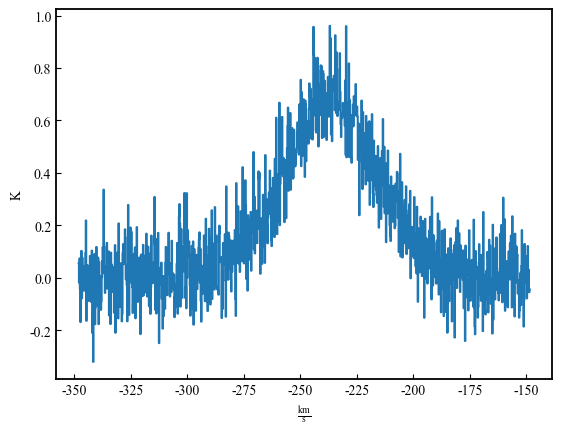

In [29]:
cube = cube.with_spectral_unit(u.km / u.s)
y, x = 11,80

spec = cube[:, y, x]
# plt.xlim(-350000,-150000)
spec.quicklook()

Loaded font file: /usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf
Matplotlib font name: Times New Roman
SpectralCube with shape=(994, 89, 153) and unit=K:
 n_x:    153  type_x: RA---CAR  unit_x: deg    range:   352.987500 deg:  356.787500 deg
 n_y:     89  type_y: DEC--CAR  unit_y: deg    range:    -6.887500 deg:   -4.687500 deg
 n_s:    994  type_s: VOPT      unit_s: km / s  range:     -348.002 km / s:    -148.527 km / s
Found 9 source CSV files.
Loaded 5922 fitted Gaussian components from merged-source CSVs.
Fit components at pixel (i=79, j=16):
   final_source_id  component  original_component_source_id  Amplitude_K  \
0                9          3                             4      0.33219   

   Velocity_kms  Sigma_kms   FWHM_kms  
0   -293.209535   9.819257  23.124351  
Reduced Chi² = 1.009
Noise sigma = 0.1036 K
Number of components = 1


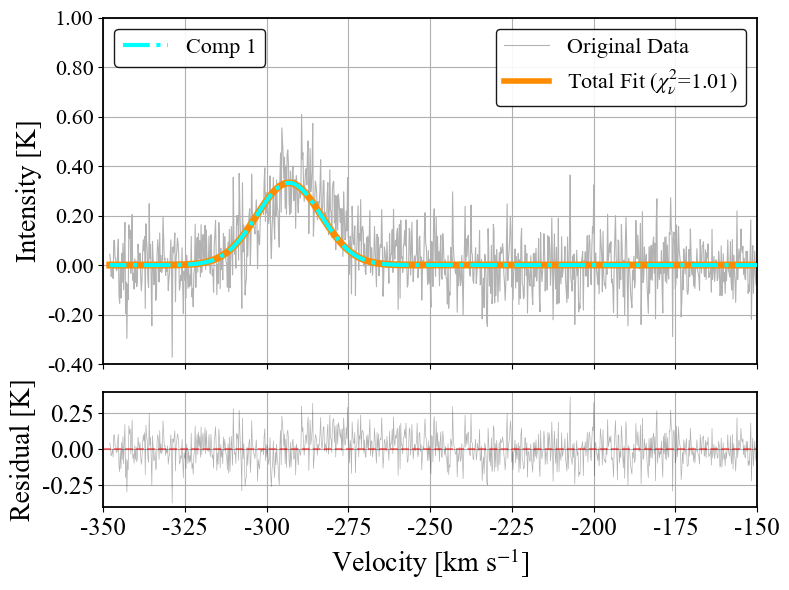

Saved figure to: ./baseline/SNR=2/output_individual_source_retest/output_merged_source_0.7/ROHSA_spectrum_i79_j16_all_sources.pdf


In [31]:
import os
import glob
import subprocess
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from astropy.io import fits
from spectral_cube import SpectralCube
import astropy.units as u
from astropy.modeling.models import Gaussian1D
from matplotlib.ticker import FormatStrFormatter
from matplotlib.lines import Line2D


# =========================================================
# 0. 设置 Times New Roman 字体
# =========================================================
def set_times_new_roman_font():
    font_loaded = False
    loaded_font_name = None

    possible_paths = [
        r"C:\Windows\Fonts\times.ttf",
        r"C:\Windows\Fonts\timesbd.ttf",
        r"C:\Windows\Fonts\timesi.ttf",
        r"C:\Windows\Fonts\timesbi.ttf",
        "/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf",
        "/usr/share/fonts/truetype/msttcorefonts/times.ttf",
        "/usr/share/fonts/TTF/Times_New_Roman.ttf",
        "/usr/local/share/fonts/Times_New_Roman.ttf",
        "/home/yx/.local/share/fonts/Times_New_Roman.ttf",
    ]

    for path in possible_paths:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            loaded_font_name = fm.FontProperties(fname=path).get_name()
            plt.rcParams["font.family"] = loaded_font_name
            mpl.rcParams["font.family"] = loaded_font_name
            font_loaded = True
            print(f"Loaded font file: {path}")
            print(f"Matplotlib font name: {loaded_font_name}")
            break

    if not font_loaded:
        try:
            font_path = subprocess.check_output(
                ["fc-match", "-f", "%{file}", "Times New Roman"],
                text=True
            ).strip()

            if font_path and os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                loaded_font_name = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams["font.family"] = loaded_font_name
                mpl.rcParams["font.family"] = loaded_font_name
                font_loaded = True
                print(f"fc-match returned font file: {font_path}")
                print(f"Matplotlib font name: {loaded_font_name}")

        except Exception as e:
            print(f"fc-match failed or Times New Roman not found: {e}")

    if not font_loaded:
        print("Times New Roman not found. Falling back to serif fonts.")
        plt.rcParams["font.family"] = "serif"
        mpl.rcParams["font.family"] = "serif"
        plt.rcParams["font.serif"] = [
            "Times New Roman",
            "Liberation Serif",
            "DejaVu Serif",
            "Times",
        ]
        mpl.rcParams["font.serif"] = [
            "Times New Roman",
            "Liberation Serif",
            "DejaVu Serif",
            "Times",
        ]

    plt.rcParams["mathtext.fontset"] = "stix"
    mpl.rcParams["mathtext.fontset"] = "stix"
    plt.rcParams["pdf.fonttype"] = 42
    plt.rcParams["ps.fonttype"] = 42
    mpl.rcParams["pdf.fonttype"] = 42
    mpl.rcParams["ps.fonttype"] = 42
    plt.rcParams["axes.unicode_minus"] = False
    mpl.rcParams["axes.unicode_minus"] = False


set_times_new_roman_font()


# =========================================================
# 1. 读取 cube
# =========================================================
cube_file = "./baseline/CRAFTS_-4.7_-350_-150_baseline.fits"

cube = SpectralCube.read(cube_file)
cube = cube.with_spectral_unit(u.km / u.s)

print(cube)


# =========================================================
# 2. 从新的 source_physical_parameters 目录读取拟合结果
# =========================================================
def standardize_columns(df):
    """
    统一新 CSV 的列名，避免大小写差异。
    """

    rename_dict = {}

    for col in df.columns:
        low = col.lower().strip()

        if low == "final_source_id":
            rename_dict[col] = "final_source_id"
        elif low == "component":
            rename_dict[col] = "component"
        elif low in [
            "original_component_source_id",
            "original_componnet_source_id",
            "component_source_id",
        ]:
            rename_dict[col] = "original_component_source_id"
        elif low == "x_pixel":
            rename_dict[col] = "x_pixel"
        elif low == "y_pixel":
            rename_dict[col] = "y_pixel"
        elif low == "amplitude_k":
            rename_dict[col] = "amplitude_K"
        elif low == "velocity_kms":
            rename_dict[col] = "velocity_kms"
        elif low == "sigma_kms":
            rename_dict[col] = "sigma_kms"
        elif low == "fwhm_kms":
            rename_dict[col] = "fwhm_kms"
        elif low == "moment0_k_kms":
            rename_dict[col] = "moment0_K_kms"

    return df.rename(columns=rename_dict)


def read_merged_source_csv_to_rohsas_format(
    source_csv_dir="./baseline/SNR=2/output_merged_source_0.7/source_physical_parameters"
):
    """
    读取新的并合源 physical csv。

    返回 result_dict:
        key = (i, j, component, original_component_source_id)
        其中 i = y_pixel, j = x_pixel

        value = {
            'source_id': final_source_id,
            'component': component,
            'original_component_source_id': original_component_source_id,
            'amplitude': Amplitude_K * u.K,
            'mean': Velocity_kms * u.km/u.s,
            'stddev': Sigma_kms * u.km/u.s,
            'fwhm': FWHM_kms * u.km/u.s,
            'csv_file': csv_file
        }
    """

    result_dict = {}

    csv_files = sorted(
        glob.glob(os.path.join(source_csv_dir, "source_*_physical_parameters.csv"))
    )

    if len(csv_files) == 0:
        raise FileNotFoundError(f"No source csv found in: {source_csv_dir}")

    print(f"Found {len(csv_files)} source CSV files.")

    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        df = standardize_columns(df)

        required_cols = [
            "final_source_id",
            "component",
            "original_component_source_id",
            "x_pixel",
            "y_pixel",
            "amplitude_K",
            "velocity_kms",
            "sigma_kms",
            "fwhm_kms",
        ]

        for col in required_cols:
            if col not in df.columns:
                raise ValueError(f"{csv_file} missing column: {col}")

        df = df.replace([np.inf, -np.inf], np.nan)
        df = df.dropna(subset=required_cols)
        df = df[df["amplitude_K"] > 0]

        for _, row in df.iterrows():
            source_id = int(row["final_source_id"])
            comp = int(row["component"])
            original_source_id = int(row["original_component_source_id"])

            x = int(row["x_pixel"])
            y = int(row["y_pixel"])

            # 为了兼容你原来 i=y, j=x 的习惯，这里 key 用 (i, j, comp, orig)
            i = y
            j = x

            key = (i, j, comp, original_source_id)

            result_dict[key] = {
                "source_id": source_id,
                "component": comp,
                "original_component_source_id": original_source_id,
                "amplitude": float(row["amplitude_K"]) * u.K,
                "mean": float(row["velocity_kms"]) * u.km / u.s,
                "stddev": float(row["sigma_kms"]) * u.km / u.s,
                "fwhm": float(row["fwhm_kms"]) * u.km / u.s,
                "csv_file": csv_file,
            }

    print(f"Loaded {len(result_dict)} fitted Gaussian components from merged-source CSVs.")

    return result_dict


# =========================================================
# 3. 获取某像素所有分量
# =========================================================
def get_all_components_at_pixel(result_dict, i, j, source_id=None):
    """
    获取某个像素点的所有 Gaussian 分量。

    Parameters
    ----------
    result_dict : dict
        read_merged_source_csv_to_rohsas_format 返回的字典。

    i, j : int
        i = y_pixel, j = x_pixel，沿用你之前的习惯。

    source_id : int or None
        如果指定，则只取某个 final source 内的分量。
        如果 None，则取该像素所有 source 中的分量。

    Returns
    -------
    comps : dict
        key = (component, original_component_source_id)
    """

    comps = {}

    for key, vals in result_dict.items():
        y, x, comp, orig_src = key

        if y == i and x == j:
            if source_id is not None and vals["source_id"] != source_id:
                continue

            comps[(comp, orig_src)] = vals

    return comps


def print_available_components_at_pixel(result_dict, i, j):
    """
    打印某个像素在新 CSV 里有哪些源和分量。
    """

    rows = []

    for key, vals in result_dict.items():
        y, x, comp, orig_src = key

        if y == i and x == j:
            rows.append(
                {
                    "final_source_id": vals["source_id"],
                    "component": comp,
                    "original_component_source_id": orig_src,
                    "Amplitude_K": vals["amplitude"].value,
                    "Velocity_kms": vals["mean"].value,
                    "Sigma_kms": vals["stddev"].value,
                    "FWHM_kms": vals["fwhm"].value,
                }
            )

    if len(rows) == 0:
        print(f"No fit data found at pixel (i={i}, j={j})")
        return pd.DataFrame()

    df = pd.DataFrame(rows).sort_values(
        ["final_source_id", "component", "original_component_source_id"]
    )

    print(f"Fit components at pixel (i={i}, j={j}):")
    print(df)

    return df


# =========================================================
# 4. 主函数：画图 + residual + chi2
# =========================================================
def plot_with_residual_and_chi2(
    cube,
    result_dict,
    i,
    j,
    source_id=None,
    output_dir="./baseline/SNR=2/output_merged_source_0.7/spectra_plots",
    xlim=(-350, -150),
    ylim=(-0.4, 1),
):
    """
    绘制某个像素点的原始谱线、ROHSA 高斯分量、总拟合和 residual。

    i = y_pixel
    j = x_pixel

    source_id:
        None: 绘制该像素所有 source 里的分量。
        int:  只绘制某个 final source 的分量。
    """

    os.makedirs(output_dir, exist_ok=True)

    # ---------- 读取谱线 ----------
    spec = cube[:, i, j]
    x = cube.spectral_axis.to(u.km / u.s).value
    y = spec.value

    mask = np.isfinite(y)
    x = x[mask]
    y = y[mask]

    # ---------- 获取高斯 ----------
    comps = get_all_components_at_pixel(
        result_dict,
        i,
        j,
        source_id=source_id,
    )

    if not comps:
        print(f"No fit data for pixel (i={i}, j={j}), source_id={source_id}")
        return None

    # ---------- 构建模型 ----------
    total_model = np.zeros_like(x)
    models = []

    colors = ["cyan", "magenta", "green", "blue", "purple", "orange"]

    for idx, ((comp, orig_src), vals) in enumerate(sorted(comps.items())):
        g = Gaussian1D(
            amplitude=vals["amplitude"].value,
            mean=vals["mean"].value,
            stddev=vals["stddev"].value,
        )
    
        y_model = g(x)
        total_model += y_model
    
        label = f"Comp {idx+1}"


        models.append(
            {
                "component": comp,
                "original_component_source_id": orig_src,
                "source_id": vals["source_id"],
                "model": y_model,
                "color": colors[idx % len(colors)],
                "label": label,
            }
        )

    # ---------- 噪声估计 ----------
    # 注意这里是 x > -195，不是 x > +195
    noise_mask = (x < -305) | (x > -195)

    if np.sum(noise_mask) < 5:
        print("Not enough channels for noise estimation.")
        sigma = np.nanstd(y)
    else:
        sigma = np.nanstd(y[noise_mask] - np.nanmean(y[noise_mask]))

    if sigma == 0 or np.isnan(sigma):
        print("Noise estimation failed!")
        return None

    # ---------- chi2 ----------
    n_params = 3 * len(comps)
    chi2 = np.sum(((y - total_model) / sigma) ** 2)
    dof = len(y) - n_params

    if dof > 0:
        chi2_red = chi2 / dof
    else:
        chi2_red = np.nan

    print(f"Reduced Chi² = {chi2_red:.3f}")
    print(f"Noise sigma = {sigma:.4f} K")
    print(f"Number of components = {len(comps)}")

    # =====================================================
    # 画图
    # =====================================================
    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=(8, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
    )

    # ---------- 上图 ----------
    ax1.plot(
        x,
        y,
        "k-",
        linewidth=0.8,
        alpha=0.3,
        label="Original Data",
        zorder=1,
    )

    ax1.plot(
        x,
        total_model,
        linestyle="-",
        color="darkorange",
        linewidth=5,
        label=rf"Total Fit ($\chi^2_\nu$={chi2_red:.2f})",
        zorder=2,
    )

    for m in models:
        ax1.plot(
            x,
            m["model"],
            linestyle="-.",
            color=m["color"],
            linewidth=3,
            zorder=3,
        )

    # ---------- 两个图例 ----------
    comp_legend_elements = [
        Line2D(
            [0],
            [0],
            color=m["color"],
            linestyle="-.",
            linewidth=3,
            label=m["label"],
        )
        for m in models
    ]

    legend1 = ax1.legend(
        handles=comp_legend_elements,
        loc="upper left",
        fontsize=16,
        framealpha=0.9,
        edgecolor="black",
        title_fontsize=12,
    )

    ax1.add_artist(legend1)

    data_legend_elements = [
        Line2D(
            [0],
            [0],
            color="black",
            linewidth=0.8,
            alpha=0.3,
            label="Original Data",
        ),
        Line2D(
            [0],
            [0],
            color="darkorange",
            linewidth=4,
            label=rf"Total Fit ($\chi^2_\nu$={chi2_red:.2f})",
        ),
    ]

    ax1.legend(
        handles=data_legend_elements,
        loc="upper right",
        fontsize=16,
        framealpha=0.9,
        edgecolor="black",
    )

    ax1.set_ylabel("Intensity [K]", fontsize=20)
    ax1.tick_params(axis="both", which="both", direction="out", labelsize=16)
    ax1.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    ax1.grid()
    ax1.set_xlim(*xlim)
    ax1.set_ylim(*ylim)

    # ---------- 下图 residual ----------
    residual = y - total_model

    ax2.plot(
        x,
        residual,
        "k-",
        linewidth=0.5,
        alpha=0.3,
    )

    ax2.axhline(
        0,
        linestyle="--",
        color="red",
        alpha=0.5,
    )

    ax2.tick_params(axis="both", which="both", direction="out", labelsize=18)
    ax2.set_xlabel("Velocity [km s$^{-1}$]", fontsize=20)
    ax2.set_ylabel("Residual [K]", fontsize=20)
    ax2.set_ylim(-0.4, 0.4)
    ax2.grid()

    # ---------- 保存 ----------
    if source_id is None:
        out_name = f"ROHSA_spectrum_i{i}_j{j}_all_sources.pdf"
    else:
        out_name = f"ROHSA_spectrum_i{i}_j{j}_source_{source_id:03d}.pdf"

    out_file = os.path.join(output_dir, out_name)

    plt.tight_layout()

    plt.savefig(
        out_file,
        bbox_inches="tight",
        dpi=300,
    )

    plt.show()

    print(f"Saved figure to: {out_file}")

    return chi2_red


# =========================================================
# 5. 主程序
# =========================================================
if __name__ == "__main__":

    source_csv_dir = "./baseline/SNR=2/output_individual_source_retest/output_merged_source_0.7/source_physical_parameters"

    pixel_results = read_merged_source_csv_to_rohsas_format(
        source_csv_dir=source_csv_dir,
    )

    # 指定像素
    # i = y_pixel, j = x_pixel
    i, j = 79,16

    # 先打印这个像素有哪些拟合分量
    print_available_components_at_pixel(
        pixel_results,
        i,
        j,
    )

    # 画该像素所有 source 中的分量
    plot_with_residual_and_chi2(
        cube,
        pixel_results,
        i,
        j,
        source_id=None,
        output_dir="./baseline/SNR=2/output_individual_source_retest/output_merged_source_0.7",
    )